In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/NER

/content/drive/MyDrive/NER


In [3]:
!pip install transformers seqeval[gpu]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=993553365f724509d678b808bf0c616fe0923a08b588f06e4e1c459daf4505f4
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


## **Fine-tuning BERT for named-entity recognition**

In this notebook, we are going to use **BertForTokenClassification** which is included in the [Transformers library](https://github.com/huggingface/transformers) by HuggingFace. This model has BERT as its base architecture, with a token classification head on top, allowing it to make predictions at the token level, rather than the sequence level. Named entity recognition is typically treated as a token classification problem, so that's what we are going to use it for.

This tutorial uses the idea of **transfer learning**, i.e. first pretraining a large neural network in an unsupervised way, and then fine-tuning that neural network on a task of interest. In this case, BERT is a neural network pretrained on 2 tasks: masked language modeling and next sentence prediction. Now, we are going to fine-tune this network on a NER dataset. Fine-tuning is supervised learning, so this means we will need a labeled dataset.

If you want to know more about BERT, I suggest the following resources:
* the original [paper](https://arxiv.org/abs/1810.04805)
* Jay Allamar's [blog post](http://jalammar.github.io/illustrated-bert/) as well as his [tutorial](http://jalammar.github.io/a-visual-guide-to-using-bert-for-the-first-time/)
* Chris Mccormick's [Youtube channel](https://www.youtube.com/channel/UCoRX98PLOsaN8PtekB9kWrw)
* Abbishek Kumar Mishra's [Youtube channel](https://www.youtube.com/user/abhisheksvnit)

The following notebook largely follows the same structure as the tutorials by Abhishek Kumar Mishra. For his tutorials on the Transformers library, see his [Github repository](https://github.com/abhimishra91/transformers-tutorials).

NOTE: this notebook assumes basic knowledge about deep learning, BERT, and native PyTorch. If you want to learn more Python, deep learning and PyTorch, I highly recommend cs231n by Stanford University and the FastAI course by Jeremy Howard et al. Both are freely available on the web.  

Now, let's move on to the real stuff!

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast, BertConfig, BertForTokenClassification

As deep learning can be accellerated a lot using a GPU instead of a CPU, make sure you can run this notebook in a GPU runtime (which Google Colab provides for free! - check "Runtime" - "Change runtime type" - and set the hardware accelerator to "GPU").

We can set the default device to GPU using the following code (if it prints "cuda", it means the GPU has been recognized):

In [3]:
from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'
print(device)

cpu


#### **Downloading and preprocessing the data**
Named entity recognition (NER) uses a specific annotation scheme, which is defined (at least for European languages) at the *word* level. An annotation scheme that is widely used is called **[IOB-tagging](https://en.wikipedia.org/wiki/Inside%E2%80%93outside%E2%80%93beginning_(tagging)**, which stands for Inside-Outside-Beginning. Each tag indicates whether the corresponding word is *inside*, *outside* or at the *beginning* of a specific named entity. The reason this is used is because named entities usually comprise more than 1 word.

Let's have a look at an example. If you have a sentence like "Barack Obama was born in Hawaï", then the corresponding tags would be   [B-PERS, I-PERS, O, O, O, B-GEO]. B-PERS means that the word "Barack" is the beginning of a person, I-PERS means that the word "Obama" is inside a person, "O" means that the word "was" is outside a named entity, and so on. So one typically has as many tags as there are words in a sentence.

So if you want to train a deep learning model for NER, it requires that you have your data in this IOB format (or similar formats such as [BILOU](https://stackoverflow.com/questions/17116446/what-do-the-bilou-tags-mean-in-named-entity-recognition)). There exist many annotation tools which let you create these kind of annotations automatically (such as Spacy's [Prodigy](https://prodi.gy/), [Tagtog](https://docs.tagtog.net/) or [Doccano](https://github.com/doccano/doccano)). You can also use Spacy's [biluo_tags_from_offsets](https://spacy.io/api/goldparse#biluo_tags_from_offsets) function to convert annotations at the character level to IOB format.

Here, we will use a NER dataset from [Kaggle](https://www.kaggle.com/namanj27/ner-dataset) that is already in IOB format. One has to go to this web page, download the dataset, unzip it, and upload the csv file to this notebook. Let's print out the first few rows of this csv file:

In [4]:
DRIVE = False

if DRIVE:
    train_data = pd.read_csv('/content/drive/MyDrive/NER/train_ner_doctored.csv')
    eval_data = pd.read_csv('/content/drive/MyDrive/NER/eval_ner_doctored.csv')
    test_data = pd.read_csv('/content/drive/MyDrive/NER/test_ner_doctored.csv')
else:
    train_data = pd.read_csv('dataset_formation/data/train_ner_doctored.csv')
    eval_data = pd.read_csv('dataset_formation/data/eval_ner_doctored.csv')
    test_data = pd.read_csv('dataset_formation/data/test_ner_doctored.csv')


In [5]:
train_data.head()

,sentence,term,word,tag,word_labels
0,նախորդ հրատարակիչը վիմագրի ծանոթագրության մեջ ...,Վիմագիր,նախորդ,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,..."
1,ոմն առյուծի հայր սխիթար ճոն հիշատակված է նաև ա...,վիմագրերից,ոմն,O,"O,O,O,O,O,O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O..."
2,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...,վիմական արձանագրությունները,պրակն,O,"O,O,O,O,O,B-INSC,I-INSC"
3,վիմագրերի առաջին հրատարակիչ ս ջզալալյանցն այս ...,Վիմագիր,վիմագրերի,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,..."
4,վիմագիրը փորագրված է բավական վերևում և որոշ հա...,վիմագիրը,վիմագիրը,B-INSC,"B-INSC,O,O,O,O,O,O,O,O,O,O,O,O,O"


In [6]:
test_data.head()

,sentence,term,word,tag,word_labels
0,վլանէս թրտաշվլանէս խաչքար է կանգնեցրել,խաչքար,վլանէս,O,"O,O,B-INSC,O,O,O,O,O,O,O"
1,սմբատ նահնշահ ովհաննես սմբատ հայոց թագավոր թթ ...,հարկ,սմբատ,O,"O,O,O,O,O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O,O..."
2,սարգիս ձորավորաց եկեղեցու վանահայր խաչքարէ կան...,խաչքար,սարգիս,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,..."
3,մարմաշեն հյ գերեզմանոց տապանագիր,տապանագիր,մարմաշեն,O,"O,O,O,B-INSC"
4,սարմաշեն գլխավոր տաճար հվ պատ արտ ոդ նվիրատվակ...,տապանագիր,սարմաշեն,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,B-INSC"


We create 2 dictionaries: one that maps individual tags to indices, and one that maps indices to their individual tags. This is necessary in order to create the labels (as computers work with numbers = indices, rather than words = tags) - see further in this notebook.

In [7]:
labels_to_ids = {k: v for v, k in enumerate(['O','B-INSC','I-INSC'])}
ids_to_labels = {v: k for v, k in enumerate(['O','B-INSC','I-INSC'])}
labels_to_ids

{'O': 0, 'B-INSC': 1, 'I-INSC': 2}

Let's verify that a random sentence and its corresponding tags are correct:

In [8]:
train_data.iloc[11].sentence

'ակնհայտ է որ վիմագիրը վկայում է մի քանի նվիրատվությունների մասին'

In [9]:
train_data.iloc[11].word_labels

'O,O,O,B-INSC,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O'

#### **Preparing the dataset and dataloader**

Now that our data is preprocessed, we can turn it into PyTorch tensors such that we can provide it to the model. Let's start by defining some key variables that will be used later on in the training/evaluation process:

In [75]:
MAX_LEN = 128 # might be a bit small
TRAIN_BATCH_SIZE = 32 # 4
VALID_BATCH_SIZE = 32 # 2
EPOCHS = 3 # 1
LEARNING_RATE = 2e-5 # 1e-05 -> For small datasets, you might even try 2e-5 or 3e-5.
MAX_GRAD_NORM = 10

BASE_MODEL = 'bert-base-multilingual-uncased' # "xlm-roberta-base" #"daviddallakyan2005/armenian-ner" # 'bert-base-multilingual-uncased'

tokenizer = BertTokenizerFast.from_pretrained(BASE_MODEL)

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/295 [00:00<?, ?B/s]

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'XLMRobertaTokenizer'. 
The class this function is called from is 'BertTokenizerFast'.


A tricky part of NER with BERT is that BERT relies on **wordpiece tokenization**, rather than word tokenization. This means that we should also define the labels at the wordpiece-level, rather than the word-level!

For example, if you have word like "Washington" which is labeled as "b-gpe", but it gets tokenized to "Wash", "##ing", "##ton", then one approach could be to handle this by only train the model on the tag labels for the first word piece token of a word (i.e. only label "Wash" with "b-gpe"). This is what was done in the original BERT paper, see Github discussion [here](https://github.com/huggingface/transformers/issues/64#issuecomment-443703063).

Note that this is a **design decision**. You could also decide to propagate the original label of the word to all of its word pieces and let the model train on this. In that case, the model should be able to produce the correct labels for each individual wordpiece. This was done in [this NER tutorial with BERT](https://github.com/chambliss/Multilingual_NER/blob/master/python/utils/main_utils.py#L118). Another design decision could be to give the first wordpiece of each word the original word label, and then use the label “X” for all subsequent subwords of that word. All of them seem to lead to good performance.

Below, we define a regular PyTorch [dataset class](https://pytorch.org/docs/stable/data.html) (which transforms examples of a dataframe to PyTorch tensors). Here, each sentence gets tokenized, the special tokens that BERT expects are added, the tokens are padded or truncated based on the max length of the model, the attention mask is created and the labels are created based on the dictionary which we defined above. Word pieces that should be ignored have a label of -100 (which is the default `ignore_index` of PyTorch's [CrossEntropyLoss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)).

For more information about BERT's inputs, see [here](https://huggingface.co/transformers/glossary.html).








In [53]:
# class dataset(Dataset):
#     def __init__(self, dataframe, tokenizer, max_len):
#         self.len = len(dataframe)
#         self.data = dataframe
#         self.tokenizer = tokenizer
#         self.max_len = max_len

#     def __getitem__(self, index):
#         # step 1: get the sentence and word labels
#         sentence = self.data.sentence[index].strip().split()
#         word_labels = self.data.word_labels[index].split(",")

#         # step 2: use tokenizer to encode sentence (includes padding/truncation up to max length)
#         # BertTokenizerFast provides a handy "return_offsets_mapping" functionality for individual tokens
        
#         encoding = self.tokenizer(sentence,
#                              is_split_into_words=True,
#                              return_offsets_mapping=True,
#                              padding='max_length',
#                              truncation=True,
#                              max_length=self.max_len)

#         # step 3: create token labels only for first word pieces of each tokenized word
#         labels = [labels_to_ids[label] for label in word_labels]
#         # code based on https://huggingface.co/transformers/custom_datasets.html#tok-ner
#         # create an empty array of -100 of length max_length
#         encoded_labels = np.ones(len(encoding["offset_mapping"]), dtype=int) * -100

#         print(sentence)
#         print(encoded_labels)
#         print(encoding["offset_mapping"])
#         print(word_labels)
#         print(len(sentence), len(word_labels), len(encoded_labels), len(encoding["offset_mapping"]))
#         # set only labels whose first offset position is 0 and the second is not 0
#         i = 0
#         for idx, mapping in enumerate(encoding["offset_mapping"]):
#             if mapping[0] == 0 and mapping[1] != 0:
#                 # overwrite label
#                 encoded_labels[idx] = labels[i] # TODO: there is an error here
#                 i += 1

#         # step 4: turn everything into PyTorch tensors
#         item = {key: torch.as_tensor(val) for key, val in encoding.items()}
#         item['labels'] = torch.as_tensor(encoded_labels)

#         return item

#     def __len__(self):
#         return self.len

In [76]:
class dataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __getitem__(self, index):
        sentence = self.data.sentence[index].strip().split()
        word_labels = self.data.word_labels[index].split(",")

        encoding = self.tokenizer(
            sentence,
            is_split_into_words=True,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        # Create aligned labels
        labels = [labels_to_ids[label] for label in word_labels]
        word_ids = encoding.word_ids(batch_index=0)

        # Initialize with -100
        encoded_labels = []
        previous_word_idx = None
        for word_idx in word_ids:
            if word_idx is None:
                encoded_labels.append(-100)
            elif word_idx != previous_word_idx:
                encoded_labels.append(labels[word_idx])
            else:
                encoded_labels.append(-100)
            previous_word_idx = word_idx

        # Convert everything to tensors
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item['labels'] = torch.tensor(encoded_labels, dtype=torch.long)

        return item

    def __len__(self):
        return len(self.data)

Now, based on the class we defined above, we can create 2 datasets, one for training and one for testing. Let's use a 80/20 split:

In [77]:
training_set = dataset(train_data, tokenizer, MAX_LEN)


In [78]:
training_set[0]

{'input_ids': tensor([     0, 144715, 170810, 153020,  43348,  34061, 106038, 151593, 171375,
          11082, 171005,    766,    349,   9686, 203844,  47074,  89293,   5572,
          63566,    349,   1531,      6,  23818,  27007, 207203,   6091,  34102,
         106378, 202124,  65497,  17002,  10535, 167052,  36234,      6,  41757,
          35516, 183430,   1267, 152216,   1754,      6,  33773, 168158,  99848,
            791,  11201, 178865,  83848,    455,  11977, 106406,  48077,   5569,
          26955,  56669,  23507,   4076,  39704,  10280,   6115, 187524,  42909,
              2,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1

In [79]:

testing_set = dataset(test_data, tokenizer, MAX_LEN)
validation_set = dataset(eval_data, tokenizer, MAX_LEN)

In [80]:
train_data.iloc[0]

sentence       նախորդ հրատարակիչը վիմագրի ծանոթագրության մեջ ...
term                                                     Վիմագիր
word                                                      նախորդ
tag                                                            O
word_labels    O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,...
Name: 0, dtype: object

Let's have a look at the first training example:

In [81]:
testing_set[0]

{'input_ids': tensor([     0,  43348, 101999,  26309,   3782,  11977, 112168,  23818,  12181,
         101999,  26309,   3782, 210847,   4066,   6969,    349, 140539, 177266,
          40445,      2,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1

Let's verify that the input ids and corresponding targets are correct:

In [82]:
train_data.head()

,sentence,term,word,tag,word_labels
0,նախորդ հրատարակիչը վիմագրի ծանոթագրության մեջ ...,Վիմագիր,նախորդ,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,..."
1,ոմն առյուծի հայր սխիթար ճոն հիշատակված է նաև ա...,վիմագրերից,ոմն,O,"O,O,O,O,O,O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O..."
2,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...,վիմական արձանագրությունները,պրակն,O,"O,O,O,O,O,B-INSC,I-INSC"
3,վիմագրերի առաջին հրատարակիչ ս ջզալալյանցն այս ...,Վիմագիր,վիմագրերի,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,..."
4,վիմագիրը փորագրված է բավական վերևում և որոշ հա...,վիմագիրը,վիմագիրը,B-INSC,"B-INSC,O,O,O,O,O,O,O,O,O,O,O,O,O"


In [83]:
for token, label in zip(tokenizer.convert_ids_to_tokens(training_set[9]["input_ids"]), training_set[9]["labels"]):
  print('{0:10}  {1}'.format(token, label))

<s>         -100
▁ծանոթ      0
▁վ          1
իմ          -100
ագիրը       -100
▁մ          0
կ           -100
րտ          -100
իչ          -100
▁ս          0
▁խ          0
ր           -100
իմ          -100
յան         -100
▁հայր       0
իկի         -100
▁օր         0
ոք          -100
▁իրականաց   0
ված         -100
▁           0
շին         -100
արար        -100
ական        -100
▁աշխատանքների  0
▁քար        0
եղ          -100
են          -100
▁           0
ապ          -100
ացույց      -100
ն           -100
▁է          0
▁մի         0
ա           -100
թ           -100
ռ           -100
իչ          -100
ք           -100
▁կամ        0
ուր         -100
ջ           -100
ը           -100
▁կառուց     0
վել         -100
▁է          0
▁           0
ոմ          -100
ն           -100
▁գ          0
աս          -100
պար         -100
▁ս          0
ող          -100
ոմ          -100
ոն          -100
յանի        -100
▁միջոցներ   0
ով          -100
▁ու         0
▁           0
ջան         -100
աս          

-100 = ignore index -> loss is not computed for these positions (CrossEntropyLoss skips them).

Now, let's define the corresponding PyTorch dataloaders:

In [84]:
train_params = {'batch_size': TRAIN_BATCH_SIZE,
                'shuffle': True,
                'num_workers': 0
                }

test_params = {'batch_size': VALID_BATCH_SIZE,
                'shuffle': True,
                'num_workers': 0
                }

valid_params = {'batch_size': VALID_BATCH_SIZE,
                'shuffle': True,
                'num_workers': 0
                }

training_loader = DataLoader(training_set, **train_params)
testing_loader = DataLoader(testing_set, **test_params)
validation_loader = DataLoader(validation_set, **test_params)

#### **Defining the model**

Here we define the model, BertForTokenClassification, and load it with the pretrained weights of "bert-base-uncased". The only thing we need to additionally specify is the number of labels (as this will determine the architecture of the classification head).

Note that only the base layers are initialized with the pretrained weights. The token classification head of top has just randomly initialized weights, which we will train, together with the pretrained weights, using our labelled dataset. This is also printed as a warning when you run the code cell below.

Then, we move the model to the GPU.

In [85]:
model = BertForTokenClassification.from_pretrained(BASE_MODEL, num_labels=len(labels_to_ids))
model.to(device)

config.json: 0.00B [00:00, ?B/s]

You are using a model of type xlm-roberta to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.


model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

ValueError: The state dictionary of the model you are trying to load is corrupted. Are you sure it was properly saved?

#### **Training the model**

Before training the model, let's perform a sanity check, which I learned thanks to Andrej Karpathy's wonderful [cs231n course](http://cs231n.stanford.edu/) at Stanford (see also his [blog post about debugging neural networks](http://karpathy.github.io/2019/04/25/recipe/)). The initial loss of your model should be close to -ln(1/number of classes) = -ln(1/17) = 2.83.

Why? Because we are using cross entropy loss. The cross entropy loss is defined as -ln(probability score of the model for the correct class). In the beginning, the weights are random, so the probability distribution for all of the classes for a given token will be uniform, meaning that the probability for the correct class will be near 1/17. The loss for a given token will thus be -ln(1/17). As PyTorch's [CrossEntropyLoss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) (which is used by `BertForTokenClassification`) uses *mean reduction* by default, it will compute the mean loss for each of the tokens in the sequence for which a label is provided.

Let's verify this:



In [64]:
inputs = training_set[2]
input_ids = inputs["input_ids"].unsqueeze(0)
attention_mask = inputs["attention_mask"].unsqueeze(0)
labels = inputs["labels"].unsqueeze(0)

input_ids = input_ids.to(device)
attention_mask = attention_mask.to(device)
labels = labels.to(device)

outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
initial_loss = outputs[0]
initial_loss

tensor(1.1173, grad_fn=<NllLossBackward0>)

This looks good. Let's also verify that the logits of the neural network have a shape of (batch_size, sequence_length, num_labels):

In [65]:
tr_logits = outputs[1]
tr_logits.shape

torch.Size([1, 128, 3])

Next, we define the optimizer. Here, we are just going to use Adam with a default learning rate. One can also decide to use more advanced ones such as AdamW (Adam with weight decay fix), which is [included](https://huggingface.co/transformers/main_classes/optimizer_schedules.html) in the Transformers repository, and a learning rate scheduler, but we are not going to do that here.

In [66]:
optimizer = torch.optim.Adam(params=model.parameters(), lr=LEARNING_RATE)

Now let's define a regular PyTorch training function. It is partly based on [a really good repository about multilingual NER](https://github.com/chambliss/Multilingual_NER/blob/master/python/utils/main_utils.py#L344).

In [67]:
# from tqdm import tqdm
# from sklearn.metrics import accuracy_score
# import torch

# def train(epoch, training_loader):
#     tr_loss, tr_accuracy = 0, 0
#     nb_tr_examples, nb_tr_steps = 0, 0
#     tr_preds, tr_labels = [], []

#     model.train()

#     # Wrap training loader in tqdm for progress bar
#     progress_bar = tqdm(training_loader, desc=f"Epoch {epoch} Training", leave=False)

#     for idx, batch in enumerate(progress_bar):
#         ids = batch['input_ids'].to(device, dtype=torch.long)
#         mask = batch['attention_mask'].to(device, dtype=torch.long)
#         labels = batch['labels'].to(device, dtype=torch.long)

#         outputs = model(input_ids=ids, attention_mask=mask, labels=labels)
#         loss = outputs.loss
#         tr_logits = outputs.logits

#         tr_loss += loss.item()
#         nb_tr_steps += 1
#         nb_tr_examples += labels.size(0)

#         # Compute accuracy
#         flattened_targets = labels.view(-1)
#         active_logits = tr_logits.view(-1, model.num_labels)
#         flattened_predictions = torch.argmax(active_logits, axis=1)
#         active_accuracy = labels.view(-1) != -100

#         labels_filtered = torch.masked_select(flattened_targets, active_accuracy)
#         preds_filtered = torch.masked_select(flattened_predictions, active_accuracy)

#         tr_labels.extend(labels_filtered)
#         tr_preds.extend(preds_filtered)

#         tmp_tr_accuracy = accuracy_score(
#             labels_filtered.cpu().numpy(),
#             preds_filtered.cpu().numpy()
#         )
#         tr_accuracy += tmp_tr_accuracy

#         # Gradient clipping + backward pass
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=MAX_GRAD_NORM)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         # Update tqdm bar
#         progress_bar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{tmp_tr_accuracy:.4f}'})

#     epoch_loss = tr_loss / nb_tr_steps
#     tr_accuracy = tr_accuracy / nb_tr_steps
#     print(f"\nEpoch {epoch} Summary:")
#     print(f"  Training loss: {epoch_loss:.4f}")
#     print(f"  Training accuracy: {tr_accuracy:.4f}")

In [68]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import torch

def train_one_epoch(epoch, model, training_loader, validation_loader, optimizer, device, ids_to_labels, eval_every=100):
    tr_loss, tr_accuracy = 0, 0
    nb_tr_steps = 0

    train_step_losses = []   # training loss every 100 steps
    eval_step_losses = []    # validation loss every 100 steps

    model.train()
    progress_bar = tqdm(training_loader, desc=f"Epoch {epoch} [Training]", leave=False)

    for idx, batch in enumerate(progress_bar):
        ids = batch['input_ids'].to(device, dtype=torch.long)
        mask = batch['attention_mask'].to(device, dtype=torch.long)
        labels = batch['labels'].to(device, dtype=torch.long)

        outputs = model(input_ids=ids, attention_mask=mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        tr_loss += loss.item()
        nb_tr_steps += 1

        # Accuracy
        flattened_targets = labels.view(-1)
        active_logits = logits.view(-1, model.num_labels)
        flattened_predictions = torch.argmax(active_logits, axis=1)
        active_mask = flattened_targets != -100

        labels_filtered = torch.masked_select(flattened_targets, active_mask)
        preds_filtered = torch.masked_select(flattened_predictions, active_mask)

        tmp_tr_accuracy = accuracy_score(
            labels_filtered.cpu().numpy(),
            preds_filtered.cpu().numpy()
        )
        tr_accuracy += tmp_tr_accuracy

        # Gradient clipping + backward
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=MAX_GRAD_NORM)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Record train loss every 100 steps
        if idx % 100 == 0:
            avg_loss = tr_loss / nb_tr_steps
            train_step_losses.append(avg_loss)

            # Run quick evaluation every 100 steps
            model.eval()
            eval_loss, eval_steps = 0, 0
            with torch.no_grad():
                for v_idx, v_batch in enumerate(validation_loader):
                    if v_idx >= 5:  # limit evaluation to 5 batches to save time
                        break
                    v_ids = v_batch['input_ids'].to(device, dtype=torch.long)
                    v_mask = v_batch['attention_mask'].to(device, dtype=torch.long)
                    v_labels = v_batch['labels'].to(device, dtype=torch.long)

                    v_outputs = model(input_ids=v_ids, attention_mask=v_mask, labels=v_labels)
                    eval_loss += v_outputs.loss.item()
                    eval_steps += 1
            model.train()

            eval_step_losses.append(eval_loss / eval_steps)

        # Update tqdm
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{tmp_tr_accuracy:.4f}'
        })

    epoch_loss = tr_loss / nb_tr_steps
    epoch_acc = tr_accuracy / nb_tr_steps

    print(f"\nEpoch {epoch} Summary:")
    print(f"  Training loss: {epoch_loss:.4f}")
    print(f"  Training accuracy: {epoch_acc:.4f}")
    print(f"  Last eval (step-level) loss: {eval_step_losses[-1]:.4f}" if eval_step_losses else "")

    return epoch_loss, epoch_acc, train_step_losses, eval_step_losses

In [72]:
EPOCHS = 3

And let's train the model!

In [73]:
# for epoch in range(EPOCHS):
#     print(f"Training epoch: {epoch + 1}")
#     train(epoch, training_loader = training_loader)

In [74]:
all_train_losses = []
all_eval_losses = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, step_train_losses, step_eval_losses = train_one_epoch(
        epoch, model, training_loader, validation_loader, optimizer, device, ids_to_labels, eval_every=100
    )
    all_train_losses.extend(step_train_losses)
    all_eval_losses.extend(step_eval_losses)

KeyboardInterrupt: 

Let's see if there's any [underfitting/overfitting](https://www.geeksforgeeks.org/machine-learning/underfitting-and-overfitting-in-machine-learning/).

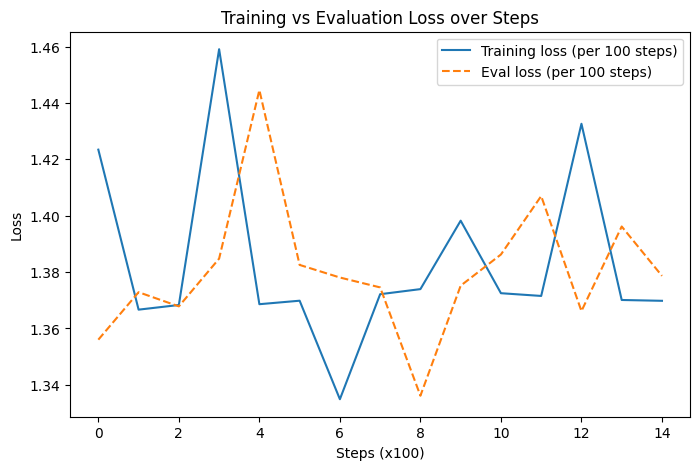

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(all_train_losses, label='Training loss (per 100 steps)')
plt.plot(all_eval_losses, label='Eval loss (per 100 steps)', linestyle='--')
plt.xlabel("Steps (x100)")
plt.ylabel("Loss")
plt.title("Training vs Evaluation Loss over Steps")
plt.legend()
plt.show()

#### **Evaluating the model**

Now that we've trained our model, we can evaluate its performance on the held-out test set (which is 20% of the data). Note that here, no gradient updates are performed, the model just outputs its logits.

In [23]:
# def valid(model, testing_loader):
#     # put model in evaluation mode
#     model.eval()

#     eval_loss, eval_accuracy = 0, 0
#     nb_eval_examples, nb_eval_steps = 0, 0
#     eval_preds, eval_labels = [], []

#     with torch.no_grad():
#         for idx, batch in enumerate(testing_loader):

#             ids = batch['input_ids'].to(device, dtype = torch.long)
#             mask = batch['attention_mask'].to(device, dtype = torch.long)
#             labels = batch['labels'].to(device, dtype = torch.long)

#             outputs = model(input_ids=ids, attention_mask=mask, labels=labels)
#             loss = outputs.loss
#             eval_logits = outputs.logits

#             eval_loss += loss.item()

#             nb_eval_steps += 1
#             nb_eval_examples += labels.size(0)

#             if idx % 100==0:
#                 loss_step = eval_loss/nb_eval_steps
#                 print(f"Validation loss per 100 evaluation steps: {loss_step}")

#             # compute evaluation accuracy
#             flattened_targets = labels.view(-1) # shape (batch_size * seq_len,)
#             active_logits = eval_logits.view(-1, model.num_labels) # shape (batch_size * seq_len, num_labels)
#             flattened_predictions = torch.argmax(active_logits, axis=1) # shape (batch_size * seq_len,)

#             # only compute accuracy at active labels
#             active_accuracy = labels.view(-1) != -100 # shape (batch_size, seq_len)

#             labels = torch.masked_select(flattened_targets, active_accuracy)
#             predictions = torch.masked_select(flattened_predictions, active_accuracy)

#             eval_labels.extend(labels)
#             eval_preds.extend(predictions)

#             tmp_eval_accuracy = accuracy_score(labels.cpu().numpy(), predictions.cpu().numpy())
#             eval_accuracy += tmp_eval_accuracy

#     labels = [ids_to_labels[id.item()] for id in eval_labels]
#     predictions = [ids_to_labels[id.item()] for id in eval_preds]

#     eval_loss = eval_loss / nb_eval_steps
#     eval_accuracy = eval_accuracy / nb_eval_steps
#     print(f"Validation Loss: {eval_loss}")
#     print(f"Validation Accuracy: {eval_accuracy}")

#     return labels, predictions

In [24]:
# from sklearn.metrics import accuracy_score
# import torch

# def valid_rough(model, testing_loader, device, ids_to_labels):
#     """
#     Evaluate token classification model while preserving sentence/chunk structure.

#     Returns:
#         labels_list: List of lists of true labels per sentence
#         predictions_list: List of lists of predicted labels per sentence
#     """
#     model.eval()
#     eval_loss = 0.0
#     nb_eval_steps = 0

#     labels_list = []
#     predictions_list = []

#     with torch.no_grad():
#         for idx, batch in enumerate(testing_loader):
#             input_ids = batch['input_ids'].to(device)
#             attention_mask = batch['attention_mask'].to(device)
#             labels = batch['labels'].to(device)

#             outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
#             loss = outputs.loss
#             logits = outputs.logits

#             eval_loss += loss.item()
#             nb_eval_steps += 1

#             # Loop over sentences in batch
#             for i in range(labels.size(0)):
#                 sentence_labels = labels[i]               # (seq_len,)
#                 sentence_logits = logits[i]               # (seq_len, num_labels)
#                 sentence_preds = torch.argmax(sentence_logits, dim=-1)

#                 # Only keep active labels (ignore -100)
#                 active_mask = sentence_labels != -100
#                 filtered_labels = sentence_labels[active_mask]
#                 filtered_preds = sentence_preds[active_mask]

#                 labels_list.append([ids_to_labels[id.item()] for id in filtered_labels])
#                 predictions_list.append([ids_to_labels[id.item()] for id in filtered_preds])

#             if idx % 100 == 0:
#                 print(f"Step {idx}: running avg validation loss = {eval_loss/nb_eval_steps:.4f}")

#     eval_loss = eval_loss / nb_eval_steps
#     print(f"\nFinal Validation Loss: {eval_loss:.4f}")

#     return labels_list, predictions_list


In [46]:
# labels, predictions = valid_rough(model, testing_loader, device, ids_to_labels)

In [48]:
import torch
from tqdm import tqdm

def predict(model, dataloader, device, ids_to_labels):
    """
    Generate predictions and ground truth labels for a token classification model.

    Args:
        model: Trained HuggingFace model (e.g., BertForTokenClassification)
        dataloader: DataLoader providing batches with 'input_ids', 'attention_mask', and 'labels'
        device: torch.device('cuda' or 'cpu')
        ids_to_labels: dict mapping label IDs to label strings

    Returns:
        labels_list: List[List[str]] — true labels per sentence (excluding padding)
        predictions_list: List[List[str]] — predicted labels per sentence (excluding padding)
    """
    model.eval()
    labels_list = []
    predictions_list = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Predicting", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            for i in range(labels.size(0)):
                sentence_labels = labels[i]               # (seq_len,)
                sentence_logits = logits[i]               # (seq_len, num_labels)
                sentence_preds = torch.argmax(sentence_logits, dim=-1)

                # Filter out ignored tokens (-100)
                active_mask = sentence_labels != -100
                filtered_labels = sentence_labels[active_mask]
                filtered_preds = sentence_preds[active_mask]

                labels_list.append([
                    ids_to_labels[id.item()] for id in filtered_labels
                ])
                predictions_list.append([
                    ids_to_labels[id.item()] for id in filtered_preds
                ])

    return labels_list, predictions_list

In [49]:
labels, predictions = predict(model, testing_loader, device, ids_to_labels)

However, the accuracy metric is misleading, as a lot of labels are "outside" (O), even after omitting predictions on the [PAD] tokens. What is important is looking at the precision, recall and f1-score of the individual tags. For this, we use the seqeval Python library:

In [50]:
from seqeval.metrics import classification_report

print(classification_report(labels, predictions, digits=4))

              precision    recall  f1-score   support

        INSC     0.0049    0.7143    0.0098        14

   micro avg     0.0049    0.7143    0.0098        14
   macro avg     0.0049    0.7143    0.0098        14
weighted avg     0.0049    0.7143    0.0098        14



Performance already seems quite good, but note that we've only trained for 1 epoch. An optimal approach would be to perform evaluation on a validation set while training to improve generalization.

In [51]:
valid_labels, valid_predictions = predict(model, validation_loader, device, ids_to_labels)
print(classification_report(valid_labels, valid_predictions, digits=4))

              precision    recall  f1-score   support

        INSC     0.0049    0.7143    0.0098        14

   micro avg     0.0049    0.7143    0.0098        14
   macro avg     0.0049    0.7143    0.0098        14
weighted avg     0.0049    0.7143    0.0098        14



## Augmented Dataset

In [54]:
train_data_aug = pd.read_csv('dataset_formation/data/train_ner_aug_doctored.csv')
# eval_data_aug= pd.read_csv('dataset_formation/data/eval_ner_aug_doctored.csv')

eval_data_aug= pd.read_csv('dataset_formation/data/eval_ner_doctored.csv') # eval simulates a real test
test_data_aug= pd.read_csv('dataset_formation/data/test_ner_doctored.csv')


In [56]:

training_set_aug = dataset(train_data_aug, tokenizer, MAX_LEN)
validation_set_aug = dataset(eval_data_aug, tokenizer, MAX_LEN)

In [57]:
training_loader_aug = DataLoader(training_set_aug, **train_params)
# validation_loader_aug = DataLoader(validation_set_aug, **test_params)

In [30]:
# for epoch in range(EPOCHS):
#     print(f"Training epoch: {epoch + 1}")
#     train(epoch,training_loader=training_loader_aug)

Training epoch: 1
Training loss per 100 training steps: 0.0
Training loss per 100 training steps: 0.0
Training loss per 100 training steps: 0.0
Training loss per 100 training steps: 0.0
Training loss epoch: 0.0
Training accuracy epoch: 0.987738681356567


In [58]:
all_train_losses = []
all_eval_losses = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, step_train_losses, step_eval_losses = train_one_epoch(
        epoch, model, training_loader_aug, validation_loader_aug, optimizer, device, ids_to_labels, eval_every=100
    )
    all_train_losses.extend(step_train_losses)
    all_eval_losses.extend(step_eval_losses)


Epoch 1 Summary:
  Training loss: 1.3748
  Training accuracy: 0.0703
  Last eval (step-level) loss: 1.3772


KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(all_train_losses, label='Training loss (per 100 steps)')
plt.plot(all_eval_losses, label='Eval loss (per 100 steps)', linestyle='--')
plt.xlabel("Steps (x100)")
plt.ylabel("Loss")
plt.title("Training vs Evaluation Loss over Steps")
plt.legend()
plt.show()

In [ ]:
test_labels, test_predictions = predict(model, testing_loader, device, ids_to_labels)
print(classification_report(test_labels, test_predictions, digits=4))

In [ ]:
valid_labels, valid_predictions = predict(model, validation_loader, device, ids_to_labels)
print(classification_report(labels, predictions, digits=4))

In [31]:
# labels, predictions = valid_rough(model, testing_loader,device,ids_to_labels)
# print(classification_report(labels, predictions,digits=4))

Step 0: running avg validation loss = 0.0006
Step 100: running avg validation loss = 0.0351

Final Validation Loss: 0.0362
              precision    recall  f1-score   support

        INSC     0.0000    0.0000    0.0000        14

   micro avg     0.0000    0.0000    0.0000        14
   macro avg     0.0000    0.0000    0.0000        14
weighted avg     0.0000    0.0000    0.0000        14



### Concatenating validation and test sets

In [ ]:
test_eval_data = pd.concat([test_data_aug, eval_data_aug], ignore_index=True)
test_eval_set = dataset(test_eval_data, tokenizer, MAX_LEN)
test_eval_loader = DataLoader(test_eval_set, **test_params)

labels, predictions = valid_rough(model, test_eval_loader,device,ids_to_labels)
print(classification_report(labels, predictions))

Step 0: running avg validation loss = 0.0270
Step 100: running avg validation loss = 0.0087
Step 200: running avg validation loss = 0.0115

Final Validation Loss: 0.0113
              precision    recall  f1-score   support

        INSC       0.87      0.92      0.90        90

   micro avg       0.87      0.92      0.90        90
   macro avg       0.87      0.92      0.90        90
weighted avg       0.87      0.92      0.90        90



In [ ]:
s = ",".join(test_eval_data['word_labels'].values)

In [ ]:
import numpy as np
np.unique(s.split(","))

s.split(",").count('B-INSC')

12

#### **Saving the model for future use**

Finally, let's save the vocabulary (.txt) file, model weights (.bin) and the model's configuration (.json) to a directory, so that both the tokenizer and model can be re-loaded using the `from_pretrained()` class method.


In [ ]:
import os

directory = "./model"

if not os.path.exists(directory):
    os.makedirs(directory)

# save vocabulary of the tokenizer
tokenizer.save_vocabulary(directory)
# save the model weights and its configuration file
model.save_pretrained(directory)
print('All files saved')
print('This tutorial is completed')

# Armenian NER Model

In [ ]:
from transformers import pipeline, AutoTokenizer, AutoModelForTokenClassification

# Load the tokenizer and model from Hugging Face Hub
model_name = "daviddallakyan2005/armenian-ner"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(model_name)

# Create NER pipeline
# Use "simple" aggregation for basic entity grouping
ner_pipeline = pipeline("ner", model=model, tokenizer=tokenizer, aggregation_strategy="simple")

# Example text
text = "վերականգնման փակագծերը կազմողը չի դրել չնայած ձեռագրում բերված լուսանկարում այդպատկերն առկաէ"

# Get predictions
entities = ner_pipeline(text)
print(entities)

# Example Output:
# [
#  {'entity_group': 'PER', 'score': 0.99..., 'word': 'Գրիգոր Նարեկացին', 'start': 0, 'end': 16},
#  {'entity_group': 'LOC', 'score': 0.98..., 'word': 'Նարեկ', 'start': 87, 'end': 92}
# ]


Device set to use cuda:0


[]


In [ ]:
train_data.iloc[0]['sentence']

'վերականգնման փակագծերը կազմողը չի դրել չնայած ձեռագրում բերված լուսանկարում այդպատկերն առկաէ'